# Student Performance: Exploratory Data Analysis

This notebook explores student demographics, preparation, and exam performance. It is designed to be rerun from a fresh kernel and ends with evidence-based findings.

## 1. Setup and data loading

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

In [20]:
# Works when the notebook is opened from the project root, notebook/, or workspace root.
candidates = [Path("data") / "stud.csv", Path("notebook") / "data" / "stud.csv", Path("Student_dashboard") / "notebook" / "data" / "stud.csv"]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data/stud.csv. Open the notebook from the project or notebook directory.")
df = pd.read_csv(DATA_PATH)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Initial inspection

Establish the dataset size, schema, data types, and descriptive statistics before analyzing it.

In [21]:
overview = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "duplicate_rows": [df.duplicated().sum()],
    "missing_cells": [df.isna().sum().sum()],
})
display(overview)
display(df.dtypes.rename("dtype").to_frame())
display(df.describe(include="all").T)

,rows,columns,duplicate_rows,missing_cells
0,1000,8,0,0


,dtype
gender,str
race_ethnicity,str
parental_level_of_education,str
lunch,str
test_preparation_course,str
math_score,int64
reading_score,int64
writing_score,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental_level_of_education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_preparation_course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math_score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading_score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing_score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


## 3. Data quality checks and feature engineering

In [22]:
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "dtype": df.dtypes.astype(str),
})
display(quality)
print(f"Duplicate rows: {df.duplicated().sum()}")

,missing_count,missing_percent,unique_values,dtype
gender,0,0.0,2,str
race_ethnicity,0,0.0,5,str
parental_level_of_education,0,0.0,6,str
lunch,0,0.0,2,str
test_preparation_course,0,0.0,2,str
math_score,0,0.0,81,int64
reading_score,0,0.0,72,int64
writing_score,0,0.0,77,int64


Duplicate rows: 0


In [23]:
score_cols = ["math_score", "reading_score", "writing_score"]
required_cols = score_cols + ["gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course"]
missing_required = sorted(set(required_cols) - set(df.columns))
if missing_required:
    raise ValueError(f"Missing expected columns: {missing_required}")
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors="coerce")
df["total_score"] = df[score_cols].sum(axis=1)
df["average_score"] = df[score_cols].mean(axis=1)
df["passed"] = (df["average_score"] >= 40).astype(int)
invalid_scores = ((df[score_cols] < 0) | (df[score_cols] > 100)).sum().sum()
print(f"Invalid score values outside 0–100: {invalid_scores}")
display(df.head())

Invalid score values outside 0–100: 0


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,passed
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,1
4,male,group C,some college,standard,none,76,78,75,229,76.333333,1


## 4. Univariate analysis

### Numeric distributions

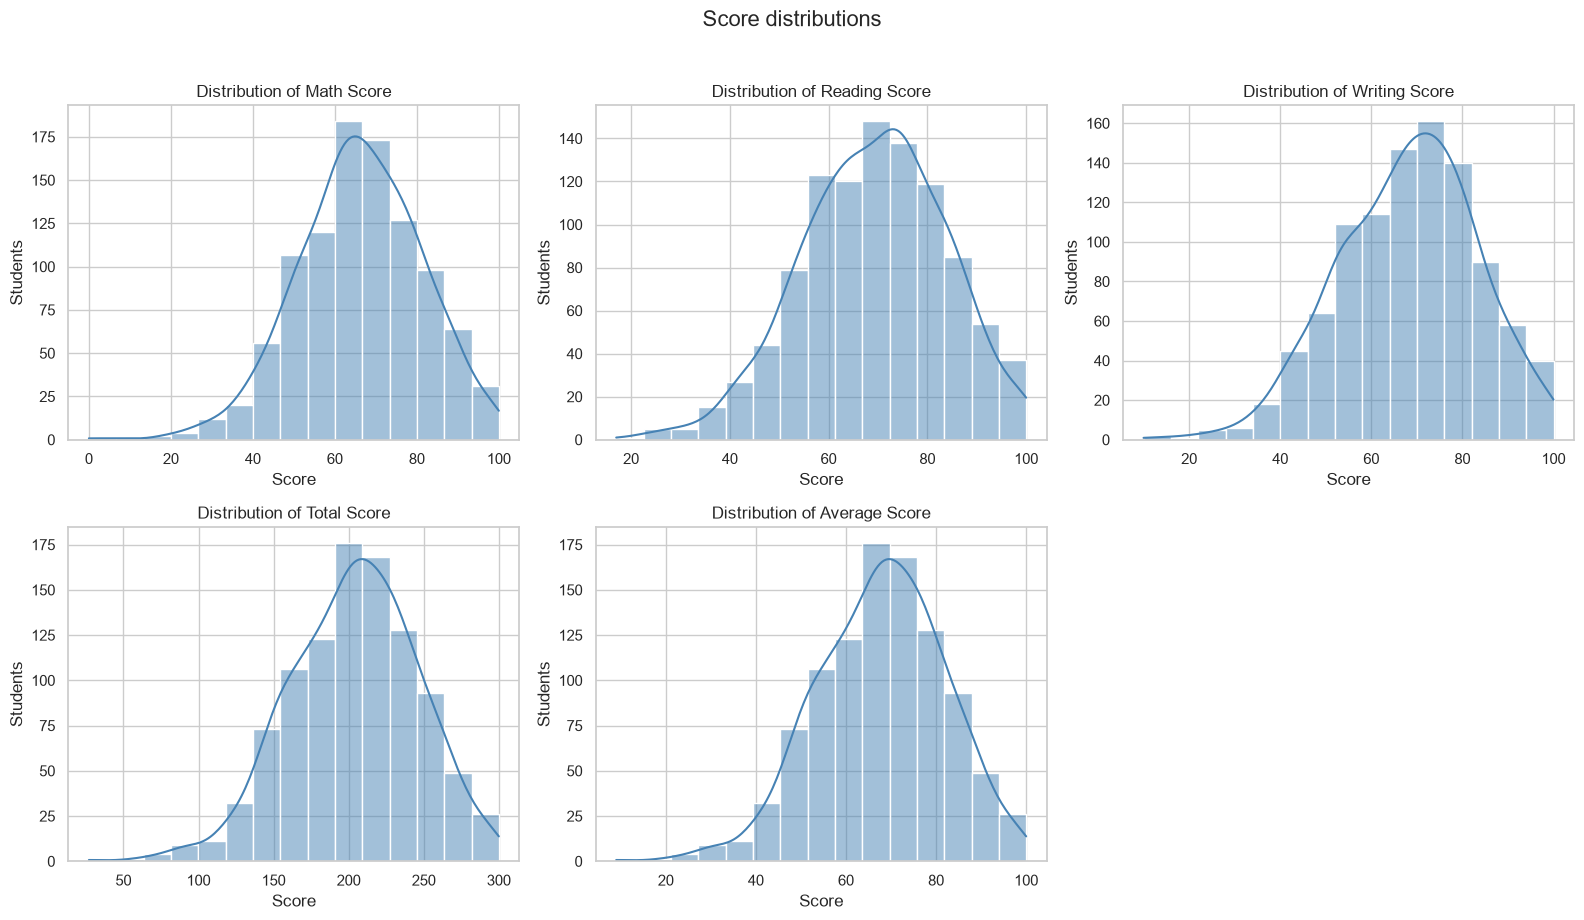

In [24]:
numeric_cols = score_cols + ["total_score", "average_score"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, bins=15, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Students")
axes.flat[-1].axis("off")
fig.suptitle("Score distributions", fontsize=16, y=1.02)
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.09,15.16,0.0,57.00,66.00,77.00,100.0
reading_score,1000.0,69.17,14.60,17.0,59.00,70.00,79.00,100.0
writing_score,1000.0,68.05,15.20,10.0,57.75,69.00,79.00,100.0
total_score,1000.0,203.31,42.77,27.0,175.00,205.00,233.00,300.0
average_score,1000.0,67.77,14.26,9.0,58.33,68.33,77.67,100.0


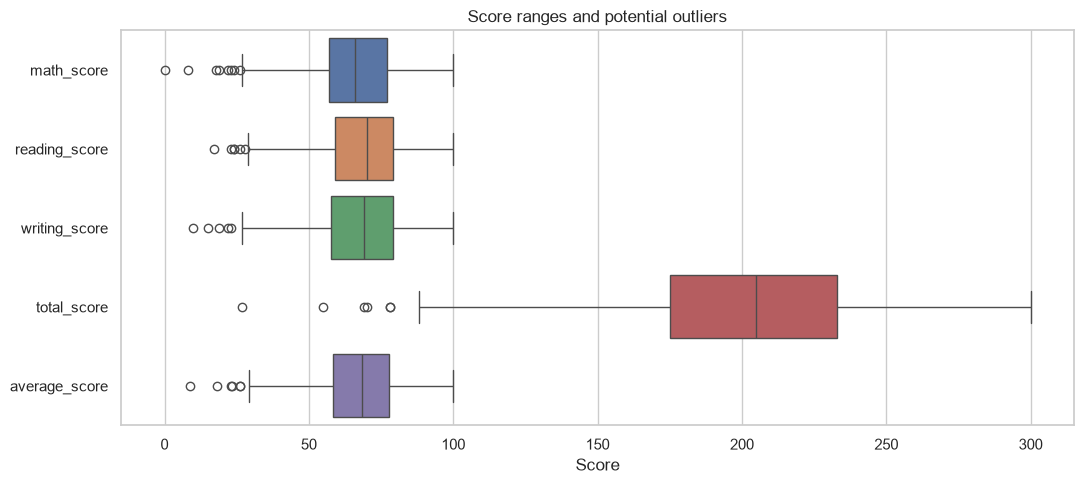

In [25]:
display(df[numeric_cols].describe().T.round(2))
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df[numeric_cols], orient="h", ax=ax)
ax.set_title("Score ranges and potential outliers")
ax.set_xlabel("Score")
plt.tight_layout()

### Categorical distributions

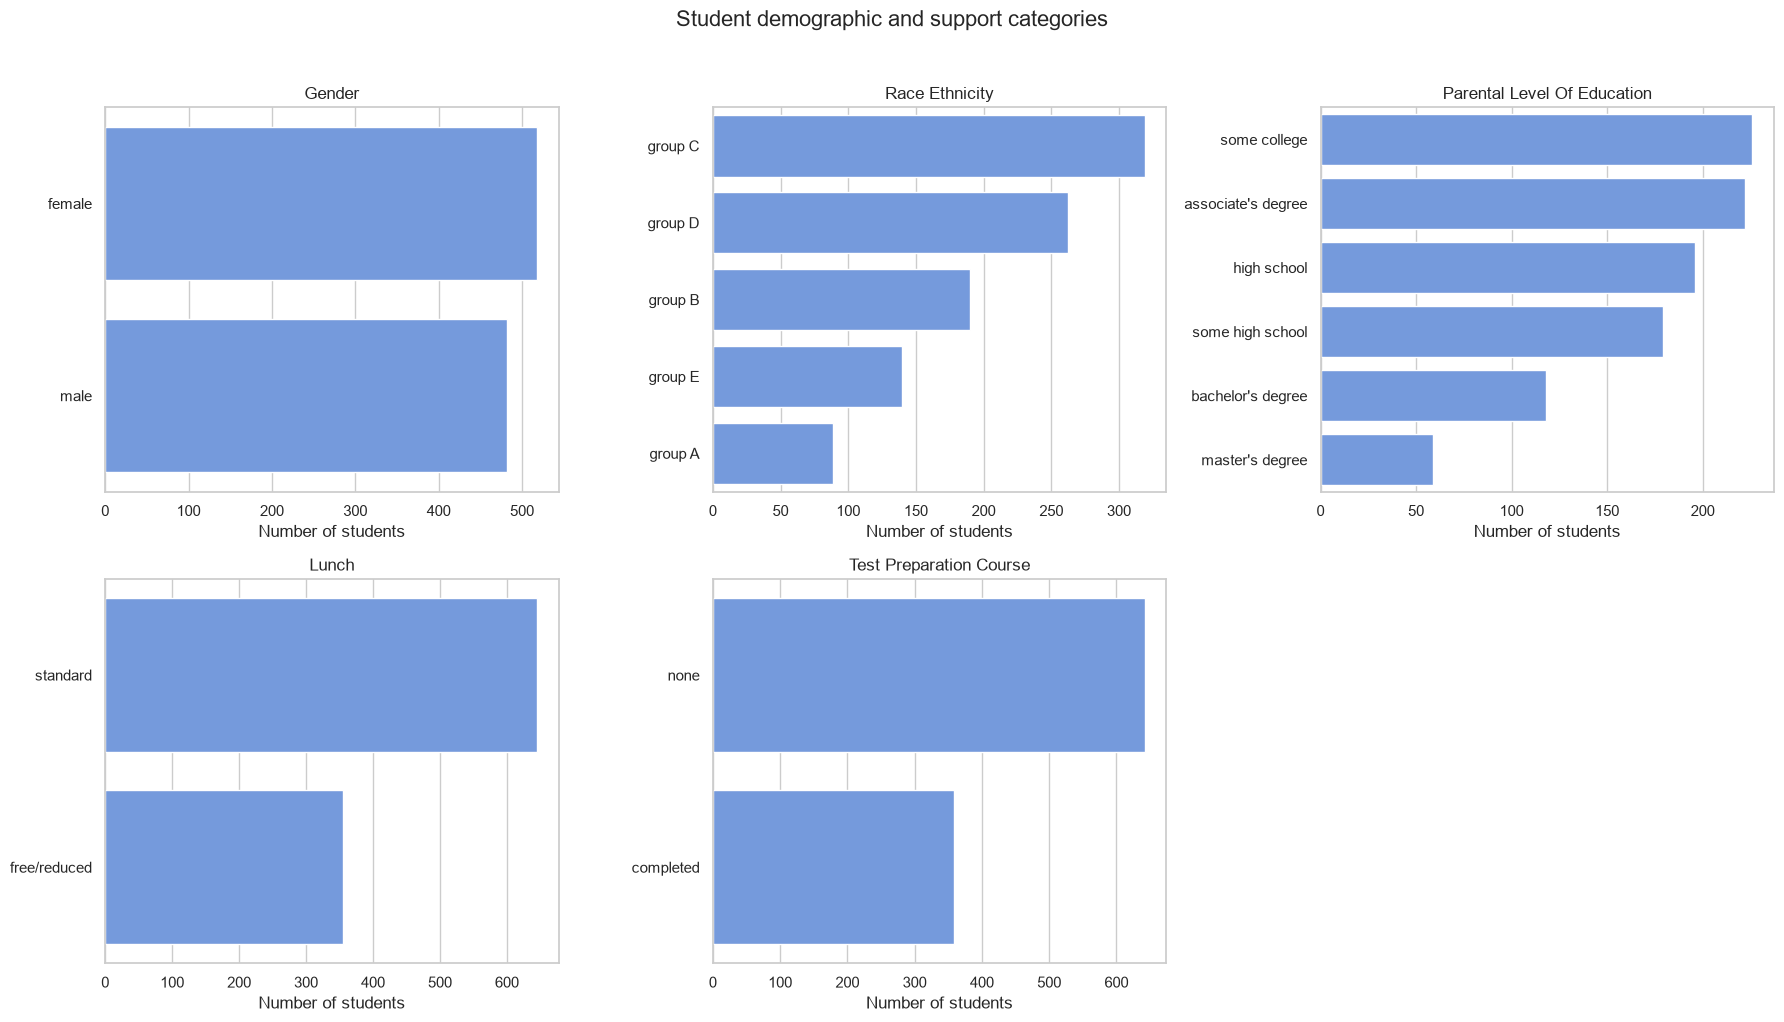

In [26]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="cornflowerblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Number of students")
    ax.set_ylabel("")
for ax in axes.flat[len(categorical_cols):]:
    ax.axis("off")
fig.suptitle("Student demographic and support categories", fontsize=16, y=1.02)
plt.tight_layout()

## 5. Bivariate analysis

Compare average performance across demographic and support variables. Bars show means with seaborn confidence intervals.

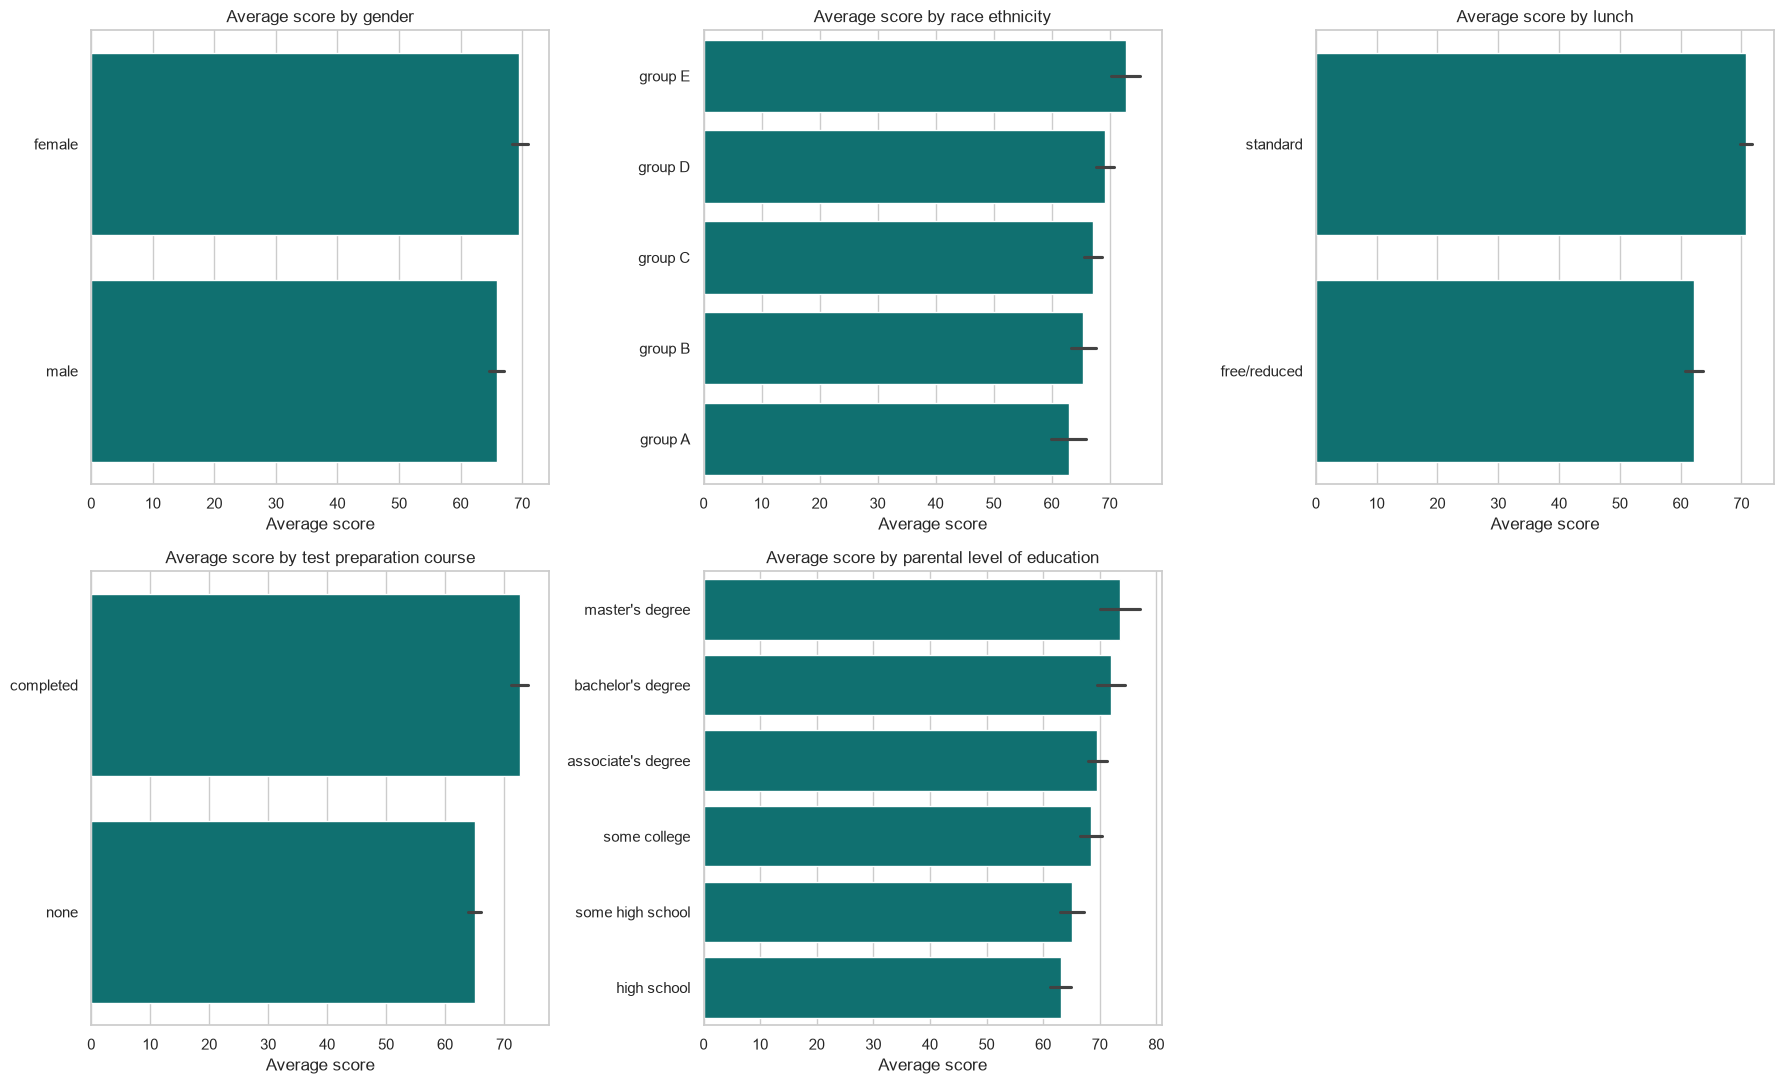

In [27]:
group_cols = ["gender", "race_ethnicity", "lunch", "test_preparation_course", "parental_level_of_education"]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, col in zip(axes.flat, group_cols):
    order = df.groupby(col)["average_score"].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x="average_score", y=col, order=order, errorbar="ci", ax=ax, color="teal")
    ax.set_title(f"Average score by {col.replace('_', ' ')}")
    ax.set_xlabel("Average score")
    ax.set_ylabel("")
for ax in axes.flat[len(group_cols):]:
    ax.axis("off")
plt.tight_layout()

In [28]:
# Group size, mean, median, and pass rate.
for col in group_cols:
    summary = (df.groupby(col, observed=True)
                .agg(students=("average_score", "size"), mean_average=("average_score", "mean"), median_average=("average_score", "median"), pass_rate=("passed", "mean"))
                .sort_values("mean_average", ascending=False))
    summary["pass_rate"] = (summary["pass_rate"] * 100).round(1)
    print(f"\n{col.replace('_', ' ').title()}")
    display(summary.round(2))


Gender


,students,mean_average,median_average,pass_rate
gender,,,,
female,518,69.57,70.33,96.9
male,482,65.84,66.33,97.1



Race Ethnicity


,students,mean_average,median_average,pass_rate
race_ethnicity,,,,
group E,140,72.75,73.50,98.6
group D,262,69.18,70.00,97.3
group C,319,67.13,68.33,96.9
group B,190,65.47,65.00,95.8
group A,89,62.99,61.33,96.6



Lunch


,students,mean_average,median_average,pass_rate
lunch,,,,
standard,645,70.84,71.33,99.1
free/reduced,355,62.20,62.67,93.2



Test Preparation Course


,students,mean_average,median_average,pass_rate
test_preparation_course,,,,
completed,358,72.67,73.50,99.2
none,642,65.04,65.33,95.8



Parental Level Of Education


,students,mean_average,median_average,pass_rate
parental_level_of_education,,,,
master's degree,59,73.60,73.33,100.0
bachelor's degree,118,71.92,71.17,98.3
associate's degree,222,69.57,69.67,99.1
some college,226,68.48,68.67,97.3
some high school,179,65.11,66.67,94.4
high school,196,63.10,65.00,94.9


## 6. Relationships between subjects

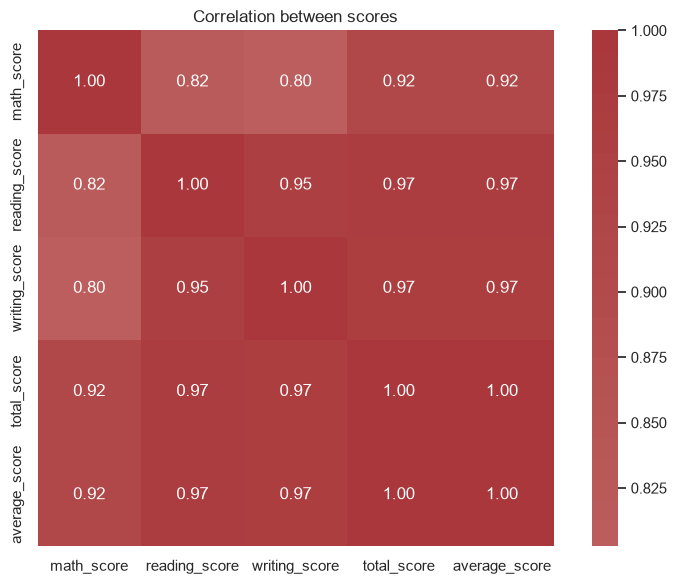

In [29]:
corr = df[score_cols + ["total_score", "average_score"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Correlation between scores")
plt.tight_layout()

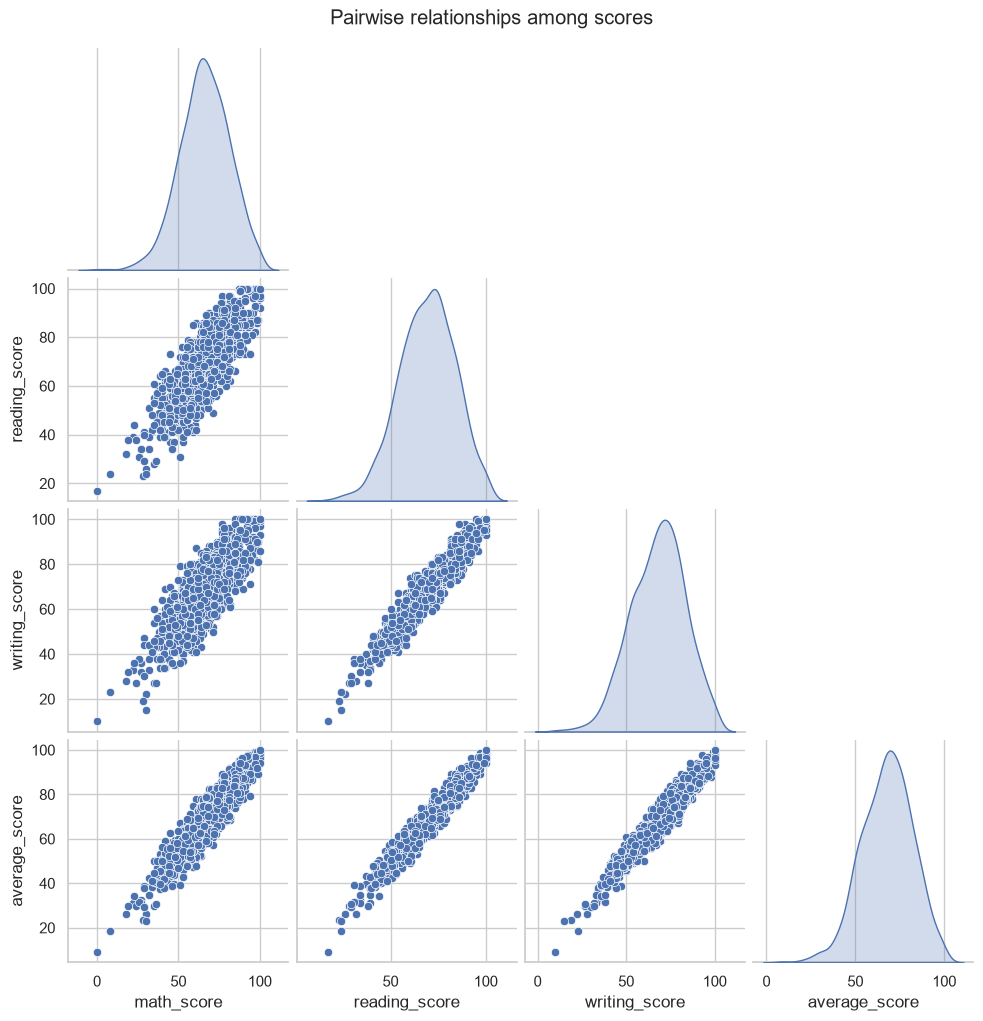

In [30]:
pair_cols = score_cols + ["average_score"]
sns.pairplot(df[pair_cols], corner=True, diag_kind="kde")
plt.suptitle("Pairwise relationships among scores", y=1.02)
plt.show()

## 7. Outlier review and findings

The IQR rule identifies unusual observations for review; it does not automatically mean that a record is erroneous.

In [31]:
outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    outlier_rows.append({"feature": col, "outlier_count": int(mask.sum()), "outlier_percent": round(mask.mean() * 100, 2)})
display(pd.DataFrame(outlier_rows))
gender_means = df.groupby("gender", observed=True)["average_score"].mean().sort_values(ascending=False)
prep_means = df.groupby("test_preparation_course", observed=True)["average_score"].mean().sort_values(ascending=False)
print(f"Highest average score by gender: {gender_means.index[0]} ({gender_means.iloc[0]:.2f})")
print(f"Highest average score by preparation status: {prep_means.index[0]} ({prep_means.iloc[0]:.2f})")
print(f"Overall average score: {df['average_score'].mean():.2f}")
print(f"Overall pass rate (average score >= 40): {df['passed'].mean() * 100:.1f}%")

,feature,outlier_count,outlier_percent
0,math_score,8,0.8
1,reading_score,6,0.6
2,writing_score,5,0.5
3,total_score,6,0.6
4,average_score,6,0.6


Highest average score by gender: female (69.57)
Highest average score by preparation status: completed (72.67)
Overall average score: 67.77
Overall pass rate (average score >= 40): 97.0%


### Interpretation checklist

- Use group summaries to identify differences, but do not interpret them as causal effects.
- Check group sizes before comparing means; small groups can be unstable.
- Treat `passed` as a simple exploratory threshold, not an official grading policy.
- For decisions, follow up with statistical tests and a clearly defined sampling strategy.